# Atividade Bônus — A: Predição de Qualidade de Sinal (5G)

**Enunciado (PGC308A):** inferir indicadores de qualidade de sinal a partir do dataset `g-nettrack`, usando técnicas de ML.

**Escolha deste projeto:** prever **`Qual`** (RSRQ em 4G/5G) com **regressão linear** e métricas de rede disponíveis no trace.

**Por que esta atividade?** É a mais simples entre as opções bônus: usa um único dataset, segue a mesma metodologia das Tasks II/III e tem interpretação clara para o relatório.

In [1]:
import sys
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FIGURES_DIR, RANDOM_STATE, RESULTS_DIR
from src.gnettrack import (
    DEFAULT_TRACE_FILES,
    FEATURE_COLUMNS,
    FEATURE_LABELS_PT,
    GNETTRACK_DIR,
    TARGET_COLUMN,
    build_modeling_frame,
    load_gnettrack,
)
from src.labels import format_model_coefficients

FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
GNETTRACK_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 0. Download dos dados (primeira execução)

Baixamos 3 traces do repositório oficial do hackathon (pedestre, carro e metrô em São Paulo).

In [2]:
BASE_URL = "https://raw.githubusercontent.com/intrig-unicamp/hackathon5G/main/datasets/g-nettrack-pro"

for filename in DEFAULT_TRACE_FILES:
    target = GNETTRACK_DIR / filename
    if target.exists():
        continue
    print(f"Baixando {filename}...")
    urllib.request.urlretrieve(f"{BASE_URL}/{filename}", target)

print("Arquivos disponíveis:")
for path in sorted(GNETTRACK_DIR.glob("*.txt")):
    print(f"  - {path.name} ({path.stat().st_size / 1024:.0f} KB)")

Arquivos disponíveis:
  - 2023-01-21_244-subway-1.txt (239 KB)
  - 2023-01-21_308-walking-paulista-1.txt (1011 KB)
  - 2023-01-22_933-driving-sp-1.txt (902 KB)


## 1. Exploração rápida

In [3]:
raw = load_gnettrack()
modeling = build_modeling_frame(raw)

resumo = pd.DataFrame(
    {
        "Etapa": ["Registros brutos", "Registros para modelagem"],
        "Quantidade": [len(raw), len(modeling)],
        "Significado": [
            "Total de linhas após unir os 3 traces G-NetTrack",
            "Linhas com todas as features e o alvo Qual preenchidos",
        ],
    }
)
display(resumo)

stats = modeling.rename(columns=FEATURE_LABELS_PT).agg(["mean", "min", "max", "std"]).T
stats.index.name = "Variável"
stats.columns = ["Média", "Mínimo", "Máximo", "Desvio padrão"]
stats.round(3)

,Etapa,Quantidade,Significado
0,Registros brutos,5259,Total de linhas após unir os 3 traces G-NetTrack
1,Registros para modelagem,4500,Linhas com todas as features e o alvo Qual pre...


,Média,Mínimo,Máximo,Desvio padrão
Variável,,,,
"Nível do sinal (RSRP, dBm)",-88.372,-118.0,-44.0,9.491
Relação sinal-ruído (SNR),2.128,-15.0,28.0,5.876
Taxa de download (kbps),6226.510,0.0,84433.0,13214.545
Taxa de upload (kbps),72.714,0.0,1032.0,133.870
Velocidade do dispositivo (km/h),23.801,0.0,76.0,24.462
Qualidade do sinal (Qual / RSRQ),-7.852,-22.0,-3.0,4.519


In [4]:
x = modeling[FEATURE_COLUMNS]
y = modeling[TARGET_COLUMN]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.30, random_state=RANDOM_STATE, shuffle=True
)

model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

metricas = pd.DataFrame(
    {
        "Métrica": ["MAE", "RMSE", "R²"],
        "Valor": [round(mae, 4), round(rmse, 4), round(r2, 4)],
        "Significado": [
            "Erro médio absoluto entre Qual medido e estimado (dB)",
            "Raiz do erro quadrático médio — penaliza erros grandes",
            "Fração da variância de Qual explicada pelo modelo (quanto mais perto de 1, melhor)",
        ],
    }
)
display(metricas)

coeficientes = format_model_coefficients(FEATURE_COLUMNS, model.coef_, model.intercept_)
coeficientes

,Métrica,Valor,Significado
0,MAE,3.2021,Erro médio absoluto entre Qual medido e estima...
1,RMSE,3.8046,Raiz do erro quadrático médio — penaliza erros...
2,R²,0.2859,Fração da variância de Qual explicada pelo mod...


,Variável,Coeficiente (Θ)
0,Level,0.042829
1,SNR,0.345953
2,DL_bitrate,0.000072
3,UL_bitrate,-0.007746
4,Speed,-0.040599
5,Intercepto (Θ₀),-3.700132


## 2. Regressão linear — prever `Qual`

- **Alvo:** `Qual` (qualidade do sinal medida pelo app)
- **Features:** Level, SNR, taxas de download/upload e velocidade
- **Validação:** 70% treino / 30% teste (`random_state=42`)

## 3. Gráficos e conclusão

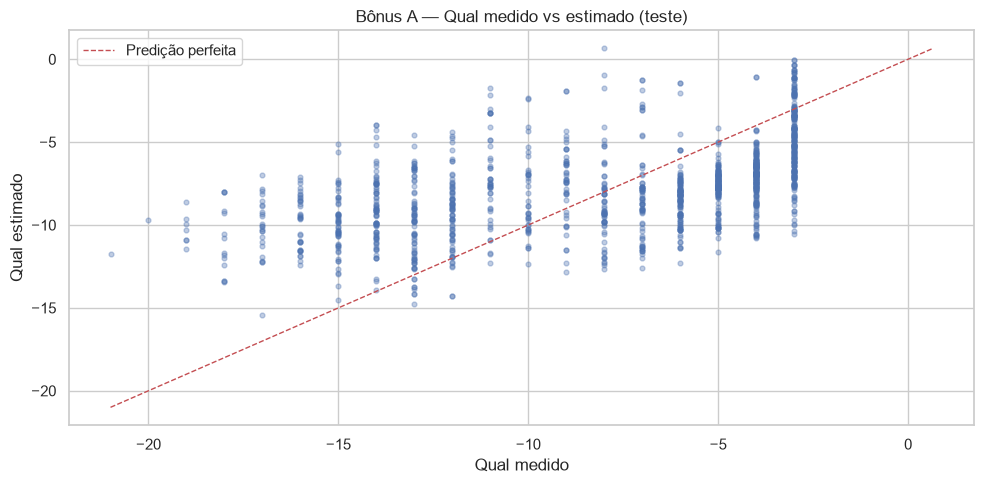

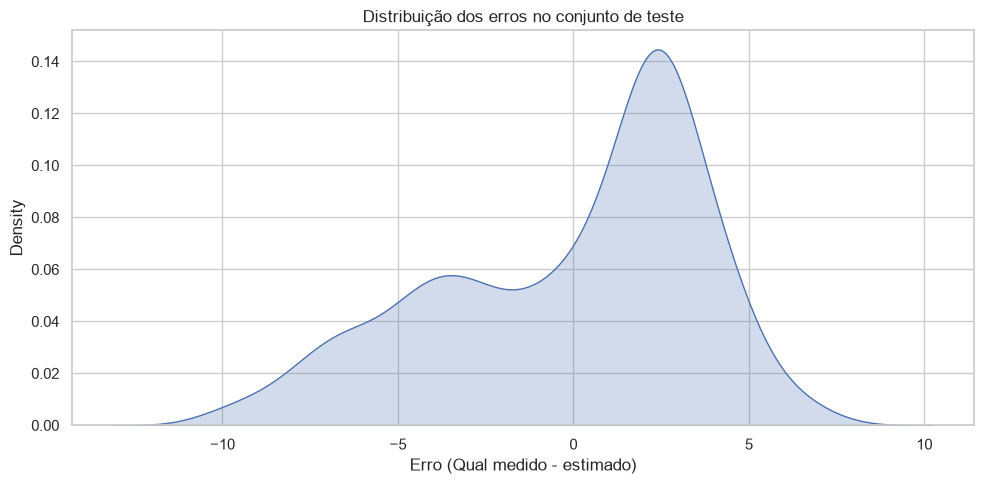

In [5]:
fig, ax = plt.subplots()
ax.scatter(y_test, y_pred, alpha=0.35, s=12)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1, label="Predição perfeita")
ax.set_xlabel("Qual medido")
ax.set_ylabel("Qual estimado")
ax.set_title("Bônus A — Qual medido vs estimado (teste)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "bonus_a_qual_scatter.png", dpi=150)
plt.show()

fig, ax = plt.subplots()
erros = y_test - y_pred
sns.kdeplot(erros, ax=ax, fill=True)
ax.set_xlabel("Erro (Qual medido - estimado)")
ax.set_title("Distribuição dos erros no conjunto de teste")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "bonus_a_erros_kde.png", dpi=150)
plt.show()

### Interpretação para o relatório

- O modelo linear captura parte da relação entre métricas de rede e `Qual` (**R²** no teste).
- **`Level`** e **`SNR`** tendem a ser os preditores mais relevantes (ver coeficientes).
- Traces de mobilidade distinta (a pé, carro, metrô) aumentam a diversidade dos dados.
- **Limitação:** não usamos enriquecimento com o dataset Mosaico/Anatel (opcional no desafio).

**Atividades bônus não escolhidas (mais complexas):**
- **B** — clusterização de tipo de mobilidade (não supervisionado, difícil validar)
- **C** — QoE de YouTube (exige cruzar `g-nettrack` + `youtube-qoe` + definir função de QoE)
- **D** — inferir ERB conectada (exige Mosaico + geoespacial)

In [6]:
metricas.to_csv(RESULTS_DIR / "bonus_a_metricas.csv", index=False)
coeficientes.to_csv(RESULTS_DIR / "bonus_a_coeficientes.csv", index=False)
print("Resultados salvos em results/")

Resultados salvos em results/
